# How have card payments in Peru evolved in recent years? Is growth shifting toward online payments? A general analysis

**Questions to be answered in this analysis**

1. Is the number of card payments growing faster than the transaction value?
2. Are online channels gaining share over offline channels?


In [7]:
import sys
from functools import reduce
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import catppuccin
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.ticker import StrMethodFormatter

from bcrp_analytics.utils import build_bcrp_dataset, get_bcrp_clean_series

pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
# TODO: create a visualization.py
plt.style.use("mocha")

# Fetch Data

In [2]:
payment_system_market = {
    # Total amount in millions
    "PN42164EM": "pago_tarjetas_total",
    "PN42165EM": "pago_tarjetas_debito",
    "PN42168EM": "pago_tarjetas_credito",
    "PN42166EM": "pago_tarjetas_debito_online",
    "PN42167EM": "pago_tarjetas_debito_offline",
    "PN42169EM": "pago_tarjetas_credito_online",
    "PN42170EM": "pago_tarjetas_credito_offline",
    # number of transactions in thousands
    "PN42193EM": "ntrx_tarjetas_total",
    "PN42194EM": "ntrx_tarjetas_debito",
    "PN42197EM": "ntrx_tarjetas_credito",
    "PN42195EM": "ntrx_tarjetas_debito_online",
    "PN42196EM": "ntrx_tarjetas_debito_offline",
    "PN42198EM": "ntrx_tarjetas_credito_online",
    "PN42199EM": "ntrx_tarjetas_credito_offline",
}

In [3]:
card_payment_data = build_bcrp_dataset(payment_system_market)

/Users/luisfernandocorcueraleon/Desktop/code/BCRP-ANALYTICS/bcrp_analytics/utils.py:158: UserWarning: Warning: Some series contain missing ovservations due to selecting series with different data ranges
  warnings.warn(


In [4]:
card_payment_data.head()

,period,pago_tarjetas_total,pago_tarjetas_debito,pago_tarjetas_credito,pago_tarjetas_debito_online,pago_tarjetas_debito_offline,pago_tarjetas_credito_online,pago_tarjetas_credito_offline,ntrx_tarjetas_total,ntrx_tarjetas_debito,ntrx_tarjetas_credito,ntrx_tarjetas_debito_online,ntrx_tarjetas_debito_offline,ntrx_tarjetas_credito_online,ntrx_tarjetas_credito_offline
0,2026-05-01,"19,238.21","8,775.25","10,462.96","3,698.54","5,076.71","3,203.81","7,259.15",198.86,144.82,54.04,63.67,81.15,11.77,42.27
1,2026-04-01,"18,998.71","8,746.70","10,252.01","4,035.90","4,710.80","3,471.16","6,780.84",191.10,140.23,50.88,63.52,76.71,11.61,39.26
2,2026-03-01,"19,842.72","9,315.71","10,527.01","3,823.01","5,492.71","3,335.00","7,192.01",190.99,138.60,52.40,52.95,85.65,11.50,40.89
3,2026-02-01,"20,514.51","11,328.43","9,186.08","6,620.42","4,708.01","2,874.08","6,312.00",173.74,127.35,46.39,54.85,72.50,10.10,36.29
4,2026-01-01,"18,047.07","8,590.24","9,456.83","3,619.78","4,970.47","2,957.57","6,499.26",181.85,133.71,48.14,56.77,76.94,10.37,37.77


# Analysis of growth between the total amount and number of transactions

## Evolution of the series over time

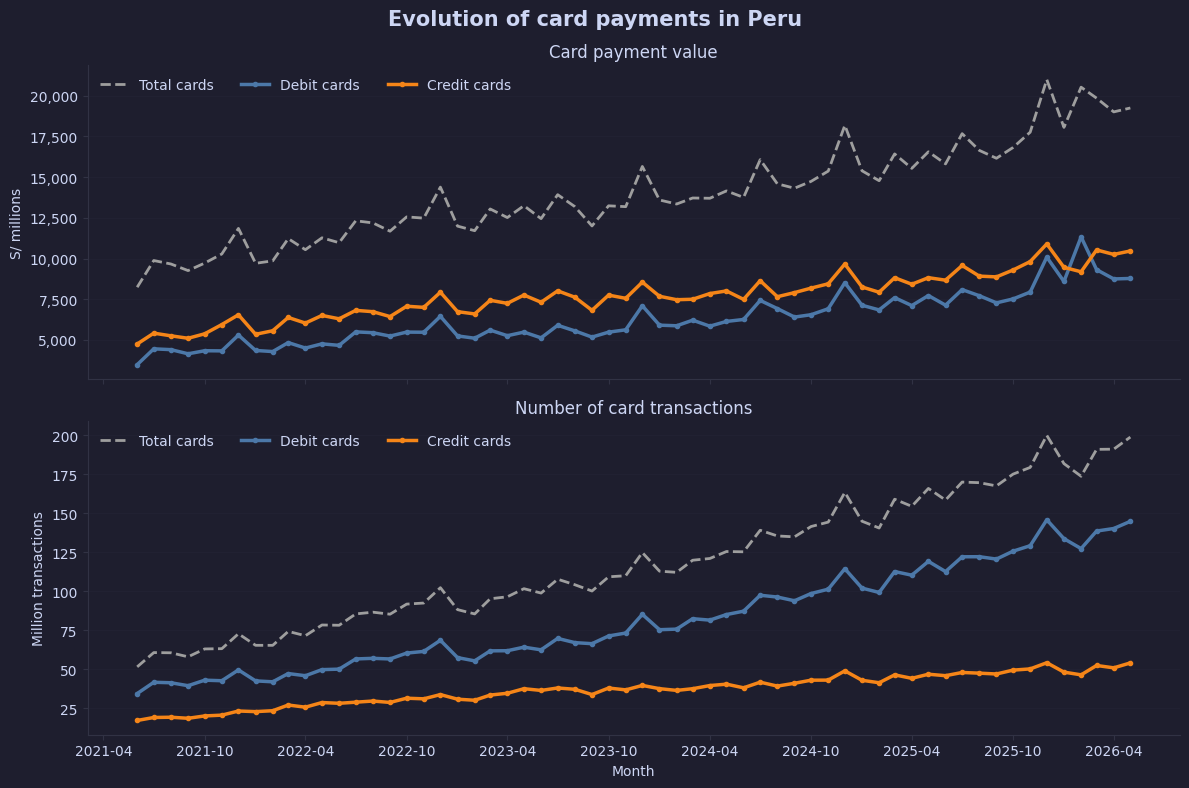

In [8]:
card_payment_data = (
    card_payment_data.sort_values("period").reset_index(drop=True).copy()
)

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True,
)

total_color = "#9E9E9E"
debit_color = "#4C78A8"
credit_color = "#F58518"

# Payment value
ax1.plot(
    card_payment_data["period"],
    card_payment_data["pago_tarjetas_total"],
    color=total_color,
    linewidth=2,
    linestyle="--",
    label="Total cards",
)

ax1.plot(
    card_payment_data["period"],
    card_payment_data["pago_tarjetas_debito"],
    color=debit_color,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Debit cards",
)

ax1.plot(
    card_payment_data["period"],
    card_payment_data["pago_tarjetas_credito"],
    color=credit_color,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Credit cards",
)

ax1.set_title("Card payment value")
ax1.set_ylabel("S/ millions")
ax1.legend(frameon=False, ncol=3)

# Number of transactions

ax2.plot(
    card_payment_data["period"],
    card_payment_data["ntrx_tarjetas_total"],
    color=total_color,
    linewidth=2,
    linestyle="--",
    label="Total cards",
)

ax2.plot(
    card_payment_data["period"],
    card_payment_data["ntrx_tarjetas_debito"],
    color=debit_color,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Debit cards",
)

ax2.plot(
    card_payment_data["period"],
    card_payment_data["ntrx_tarjetas_credito"],
    color=credit_color,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Credit cards",
)

ax2.set_title("Number of card transactions")
ax2.set_ylabel("Million transactions")
ax2.set_xlabel("Month")
ax2.legend(frameon=False, ncol=3)


for ax in (ax1, ax2):
    ax.grid(axis="y", alpha=0.20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

fig.suptitle(
    "Evolution of card payments in Peru",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

# Monthly growh

In [ ]:
card_types = {
    "total": {
        "payment": "pago_tarjetas_total",
        "transactions": "ntrx_tarjetas_total",
    },
    "debit": {
        "payment": "pago_tarjetas_debito",
        "transactions": "ntrx_tarjetas_debito",
    },
    "credit": {
        "payment": "pago_tarjetas_credito",
        "transactions": "ntrx_tarjetas_credito",
    },
}

for card_type, columns in card_types.items():

    card_payment_data[f"{card_type}_payment_mom"] = (
        card_payment_data[columns["payment"]].pct_change().mul(100)
    )

    card_payment_data[f"{card_type}_transactions_mom"] = (
        card_payment_data[columns["transactions"]].pct_change().mul(100)
    )

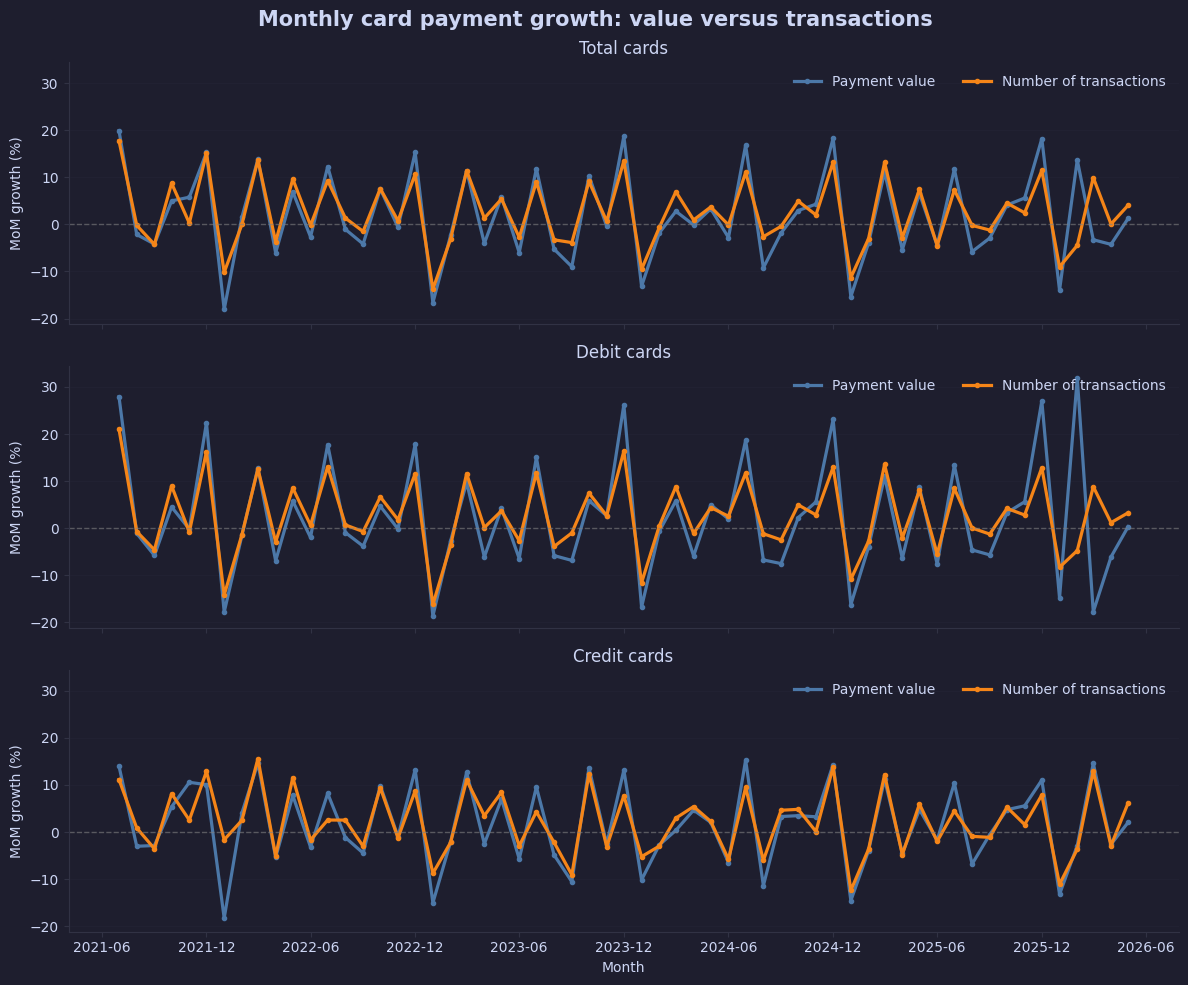

In [15]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 10),
    sharex=True,
    sharey=True,
)

payment_color = "#4C78A8"
transactions_color = "#F58518"

plot_config = [
    ("Total cards", "total"),
    ("Debit cards", "debit"),
    ("Credit cards", "credit"),
]

for ax, (title, card_type) in zip(axes, plot_config):

    ax.plot(
        card_payment_data["period"],
        card_payment_data[f"{card_type}_payment_mom"],
        color=payment_color,
        linewidth=2.3,
        marker="o",
        markersize=3,
        label="Payment value",
    )

    ax.plot(
        card_payment_data["period"],
        card_payment_data[f"{card_type}_transactions_mom"],
        color=transactions_color,
        linewidth=2.3,
        marker="o",
        markersize=3,
        label="Number of transactions",
    )

    ax.axhline(
        y=0,
        color="gray",
        linewidth=1,
        linestyle="--",
        alpha=0.6,
    )

    ax.set_title(title)
    ax.set_ylabel("MoM growth (%)")
    ax.legend(
        frameon=False,
        ncol=2,
        loc="upper right",
    )

    ax.grid(axis="y", alpha=0.20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Month")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

fig.suptitle(
    "Monthly card payment growth: value versus transactions",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

## Internual growth analysis

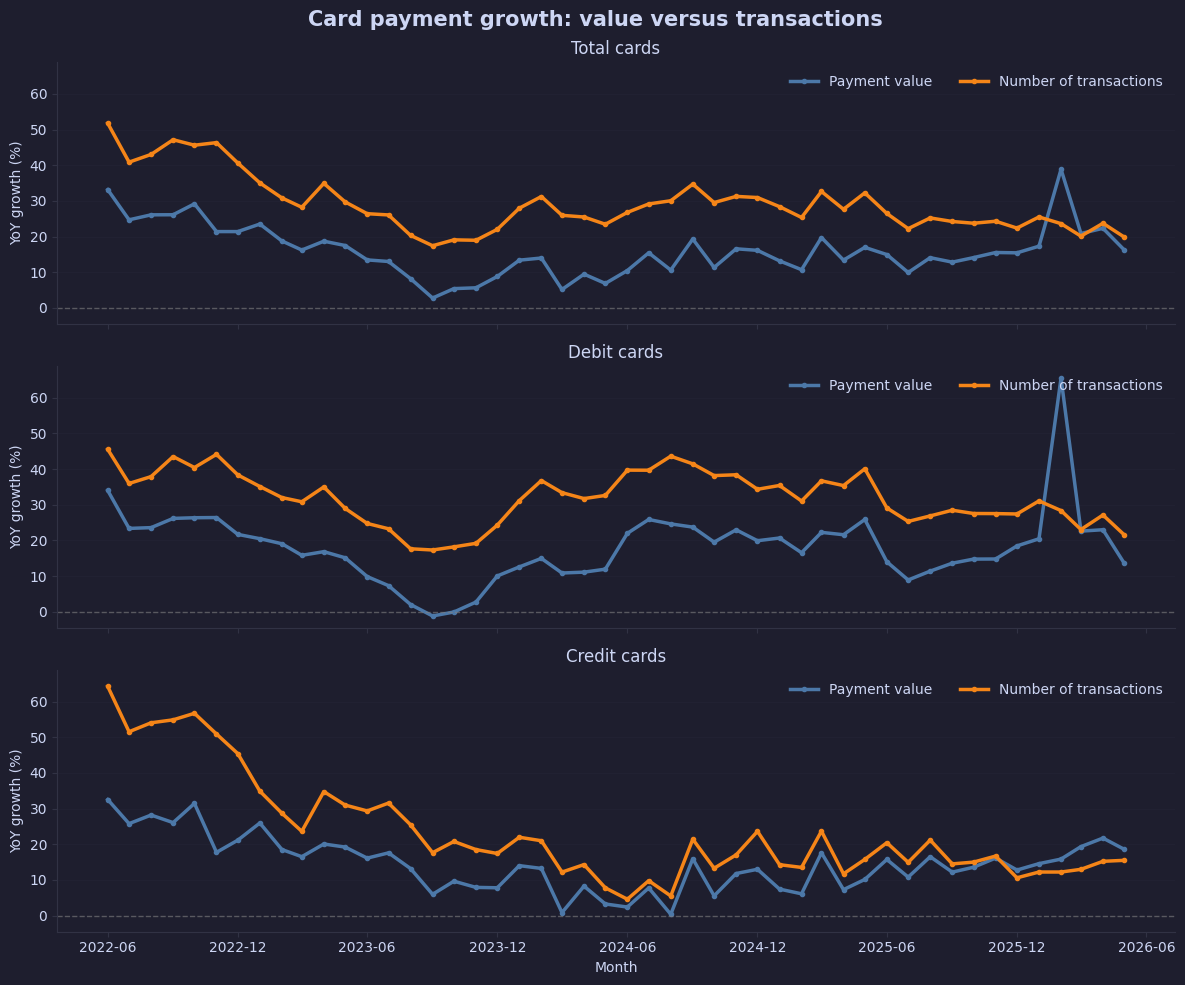

In [ ]:
for card_type, columns in card_types.items():

    card_payment_data[f"{card_type}_payment_yoy"] = (
        card_payment_data[columns["payment"]].pct_change(12).mul(100)
    )

    card_payment_data[f"{card_type}_transactions_yoy"] = (
        card_payment_data[columns["transactions"]].pct_change(12).mul(100)
    )

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 10),
    sharex=True,
    sharey=True,
)

payment_color = "#4C78A8"
transactions_color = "#F58518"

plot_config = [
    ("Total cards", "total"),
    ("Debit cards", "debit"),
    ("Credit cards", "credit"),
]

for ax, (title, card_type) in zip(axes, plot_config):

    ax.plot(
        card_payment_data["period"],
        card_payment_data[f"{card_type}_payment_yoy"],
        color=payment_color,
        linewidth=2.5,
        marker="o",
        markersize=3,
        label="Payment value",
    )

    ax.plot(
        card_payment_data["period"],
        card_payment_data[f"{card_type}_transactions_yoy"],
        color=transactions_color,
        linewidth=2.5,
        marker="o",
        markersize=3,
        label="Number of transactions",
    )

    ax.axhline(
        y=0,
        color="gray",
        linewidth=1,
        linestyle="--",
        alpha=0.6,
    )

    ax.set_title(title)
    ax.set_ylabel("YoY growth (%)")
    ax.legend(
        frameon=False,
        ncol=2,
        loc="upper right",
    )

    ax.grid(axis="y", alpha=0.20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Month")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

fig.suptitle(
    "Card payment growth: value versus transactions",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

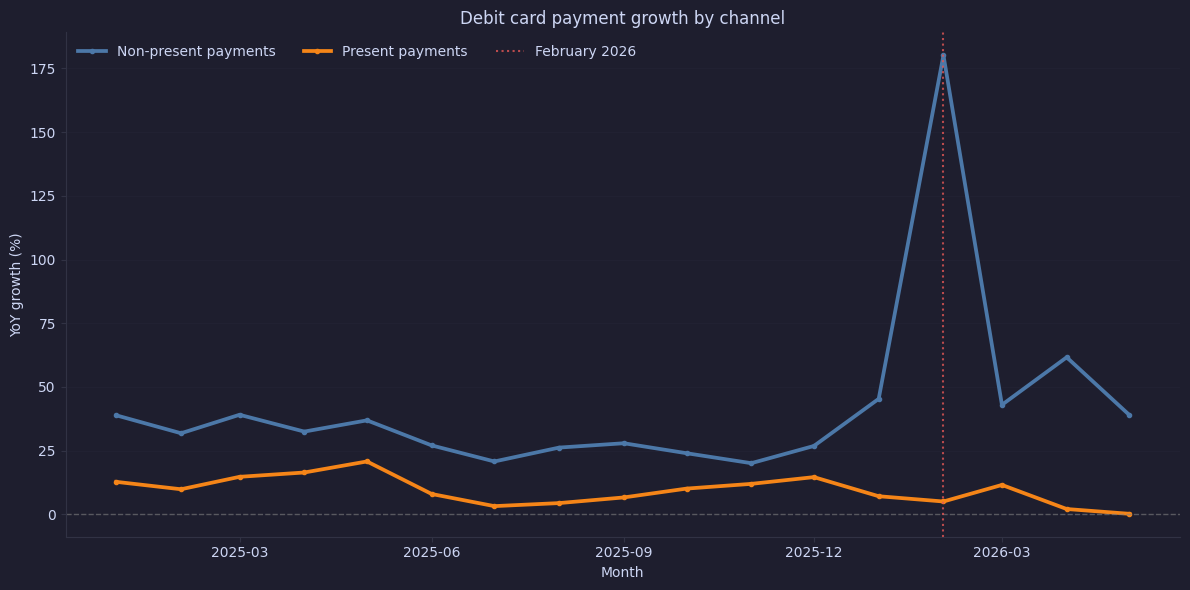

In [25]:
card_payment_data["debit_online_payment_yoy"] = (
    card_payment_data["pago_tarjetas_debito_online"].pct_change(12).mul(100)
)

card_payment_data["debit_offline_payment_yoy"] = (
    card_payment_data["pago_tarjetas_debito_offline"].pct_change(12).mul(100)
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    card_payment_data["period"],
    card_payment_data["debit_online_payment_yoy"],
    color="#4C78A8",
    linewidth=2.7,
    marker="o",
    markersize=3,
    label="Non-present payments",
)

ax.plot(
    card_payment_data["period"],
    card_payment_data["debit_offline_payment_yoy"],
    color="#F58518",
    linewidth=2.7,
    marker="o",
    markersize=3,
    label="Present payments",
)

ax.axhline(
    0,
    color="gray",
    linewidth=1,
    linestyle="--",
    alpha=0.6,
)

ax.axvline(
    pd.Timestamp("2026-02-01"),
    color="#E45756",
    linewidth=1.5,
    linestyle=":",
    alpha=0.8,
    label="February 2026",
)

ax.set_title("Debit card payment growth by channel")
ax.set_ylabel("YoY growth (%)")
ax.set_xlabel("Month")
ax.legend(frameon=False, ncol=3)
ax.grid(axis="y", alpha=0.20)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.show()

In [17]:
card_payment_data.tail()

,period,pago_tarjetas_total,pago_tarjetas_debito,pago_tarjetas_credito,pago_tarjetas_debito_online,pago_tarjetas_debito_offline,pago_tarjetas_credito_online,pago_tarjetas_credito_offline,ntrx_tarjetas_total,ntrx_tarjetas_debito,ntrx_tarjetas_credito,ntrx_tarjetas_debito_online,ntrx_tarjetas_debito_offline,ntrx_tarjetas_credito_online,ntrx_tarjetas_credito_offline,payment_reconciliation_gap,transactions_reconciliation_gap,total_payment_yoy,total_transactions_yoy,debit_payment_yoy,debit_transactions_yoy,credit_payment_yoy,credit_transactions_yoy,total_payment_mom,total_transactions_mom,debit_payment_mom,debit_transactions_mom,credit_payment_mom,credit_transactions_mom
55,2026-01-01,"18,047.07","8,590.24","9,456.83","3,619.78","4,970.47","2,957.57","6,499.26",181.85,133.71,48.14,56.77,76.94,10.37,37.77,0.00,0.00,17.30,25.49,20.46,31.07,14.57,12.22,-13.98,-9.05,-14.82,-8.30,-13.21,-11.10
56,2026-02-01,"20,514.51","11,328.43","9,186.08","6,620.42","4,708.01","2,874.08","6,312.00",173.74,127.35,46.39,54.85,72.50,10.10,36.29,0.00,0.00,38.85,23.62,65.50,28.37,15.85,12.23,13.67,-4.46,31.88,-4.75,-2.86,-3.64
57,2026-03-01,"19,842.72","9,315.71","10,527.01","3,823.01","5,492.71","3,335.00","7,192.01",190.99,138.60,52.40,52.95,85.65,11.50,40.89,0.00,0.00,20.85,20.11,22.61,23.05,19.34,12.98,-3.27,9.93,-17.77,8.83,14.60,12.95
58,2026-04-01,"18,998.71","8,746.70","10,252.01","4,035.90","4,710.80","3,471.16","6,780.84",191.10,140.23,50.88,63.52,76.71,11.61,39.26,-0.00,0.00,22.31,23.72,23.00,27.12,21.74,15.23,-4.25,0.06,-6.11,1.17,-2.61,-2.90
59,2026-05-01,"19,238.21","8,775.25","10,462.96","3,698.54","5,076.71","3,203.81","7,259.15",198.86,144.82,54.04,63.67,81.15,11.77,42.27,-0.00,-0.00,16.24,19.84,13.57,21.55,18.58,15.50,1.26,4.06,0.33,3.28,2.06,6.21


In [20]:
8590.24 + 9456.83

18047.07

## Main findings: card payment evolution

### 1. Card payments continue to grow

- Both payment value and number of transactions show a clear upward trend since 2024
- Debit and credit cards generally follow similar monthly patterns
- Debit cards account for more transactions, while credit cards usually represent a higher payment value
- Debit card transactions have grown faster than credit card transactions during the analyzed period
- February 2026 is the only month in which debit card value temporarily exceeds credit card value. This appears to be an exceptional observation rather than a structural change.

### 2. Payment value appears more volatile than transaction volume

- Monthly payment value appears more volatile than the number of transactions.
- Payment value usually increases more strongly during positive months, but it also records larger declines.
- In some months, the number of transactions increases or remains stable while payment value decreases.
- This pattern is visible for both debit and credit cards, although credit card value appears relatively more stable.
- Monthly changes are strongly affected by seasonality, especially around December and January.

### 3. Transactions have generally grown faster than payment value

- During most of the analyzed period, the number of transactions grew faster year over year than payment value.
- This pattern appears in total card payments and in both debit and credit cards.
- It indicates that the average card payment became smaller over time.
- Since late 2025, the difference between transaction growth and payment-value growth has narrowed.
- For credit cards, payment value has recently started to grow faster than the number of transactions.
- For debit cards and total payments, transaction growth remains slightly higher, excluding the exceptional observation in February 2026.

This recent convergence suggests that the decline in the average payment value may be slowing down. For credit cards, the average payment value may already be recovering.

### 4. Exceptional debit card observation in February 2026

- February 2026 shows an unusual increase in debit card payment value.
- The increase is concentrated in non-present debit card payments denominated in domestic currency.
- The additional amount is close to S/3 billion compared with January.
- The number of debit card transactions does not show a similar increase.
- Credit card payments, Culqi data and the BCRP acquiring-market series do not show an equivalent movement.
- The acquiring-market series has a narrower coverage and excludes categories such as government, financial institutions, public services, some on-us transactions and payments processed by foreign acquirers.

No public event or report has been identified that clearly explains this movement. A methodological query is being prepared for the BCRP.

Until the observation is clarified, February 2026 should be treated as an exceptional data point and should not be used as evidence of a structural market change.

# Ticket analysis

In [26]:
# Average ticket in soles per transaction

card_payment_data["ticket_total"] = (
    card_payment_data["pago_tarjetas_total"] / card_payment_data["ntrx_tarjetas_total"]
)

card_payment_data["ticket_debito"] = (
    card_payment_data["pago_tarjetas_debito"]
    / card_payment_data["ntrx_tarjetas_debito"]
)

card_payment_data["ticket_credito"] = (
    card_payment_data["pago_tarjetas_credito"]
    / card_payment_data["ntrx_tarjetas_credito"]
)

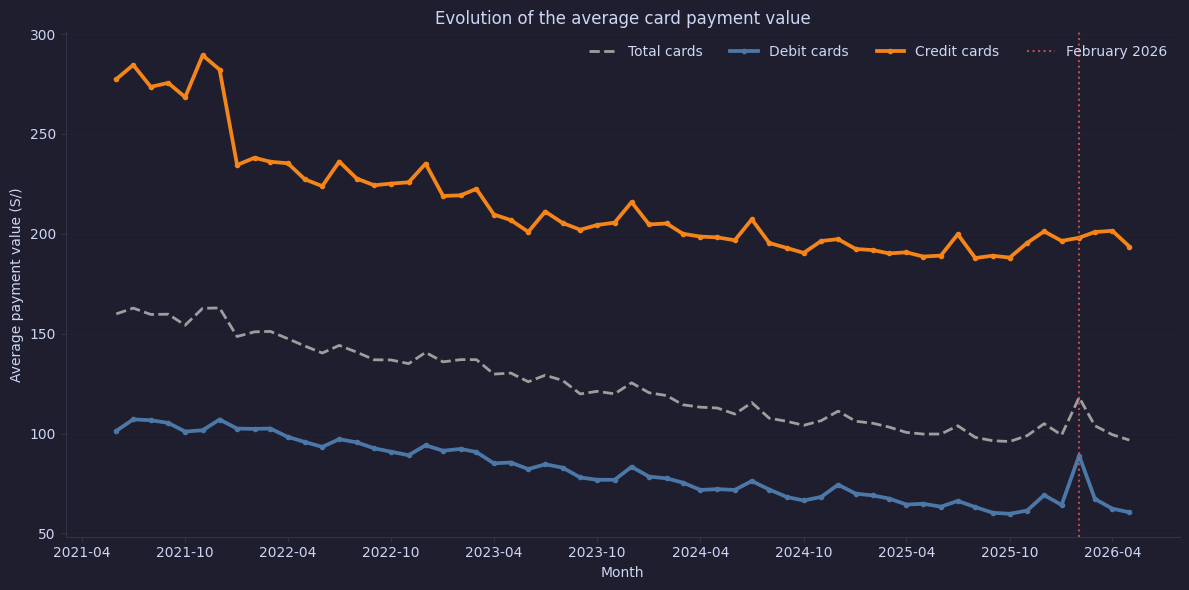

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

total_color = "#9E9E9E"
debit_color = "#4C78A8"
credit_color = "#F58518"

ax.plot(
    card_payment_data["period"],
    card_payment_data["ticket_total"],
    color=total_color,
    linewidth=2,
    linestyle="--",
    label="Total cards",
)

ax.plot(
    card_payment_data["period"],
    card_payment_data["ticket_debito"],
    color=debit_color,
    linewidth=2.7,
    marker="o",
    markersize=3,
    label="Debit cards",
)

ax.plot(
    card_payment_data["period"],
    card_payment_data["ticket_credito"],
    color=credit_color,
    linewidth=2.7,
    marker="o",
    markersize=3,
    label="Credit cards",
)

# Mark the exceptional observation
ax.axvline(
    pd.Timestamp("2026-02-01"),
    color="#E45756",
    linewidth=1.5,
    linestyle=":",
    alpha=0.8,
    label="February 2026",
)

ax.set_title("Evolution of the average card payment value")
ax.set_ylabel("Average payment value (S/)")
ax.set_xlabel("Month")

ax.legend(
    frameon=False,
    ncol=4,
    loc="upper right",
)

ax.grid(axis="y", alpha=0.20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.show()

In [40]:
# Aggregate payment value by channel
channel_data["payment_present"] = (
    channel_data["pago_tarjetas_debito_offline"]
    + channel_data["pago_tarjetas_credito_offline"]
)

channel_data["payment_non_present"] = (
    channel_data["pago_tarjetas_debito_online"]
    + channel_data["pago_tarjetas_credito_online"]
)

# Aggregate number of transactions by channel
channel_data["transactions_present"] = (
    channel_data["ntrx_tarjetas_debito_offline"]
    + channel_data["ntrx_tarjetas_credito_offline"]
)

channel_data["transactions_non_present"] = (
    channel_data["ntrx_tarjetas_debito_online"]
    + channel_data["ntrx_tarjetas_credito_online"]
)

# Average ticket
channel_data["avg_ticket_present"] = (
    channel_data["payment_present"] / channel_data["transactions_present"]
)

channel_data["avg_ticket_non_present"] = (
    channel_data["payment_non_present"] / channel_data["transactions_non_present"]
)

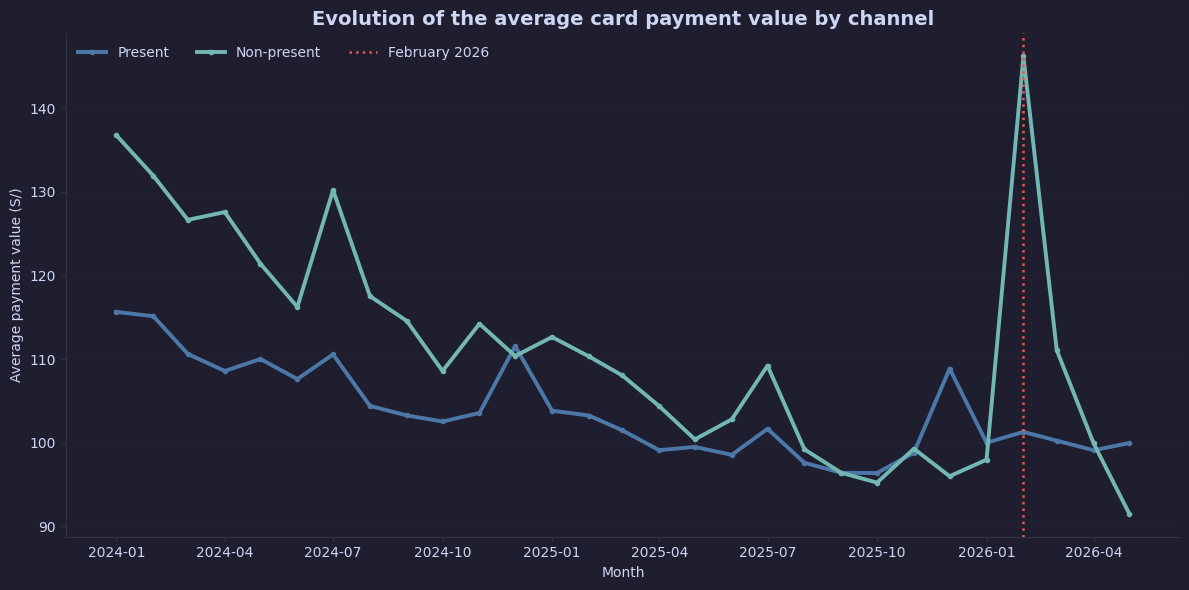

In [41]:
# Plot

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    channel_data["period"],
    channel_data["avg_ticket_present"],
    color="#4C78A8",
    linewidth=2.8,
    marker="o",
    markersize=3,
    label="Present",
)

ax.plot(
    channel_data["period"],
    channel_data["avg_ticket_non_present"],
    color="#72B7B2",
    linewidth=2.8,
    marker="o",
    markersize=3,
    label="Non-present",
)

# February 2026 anomaly
ax.axvline(
    pd.Timestamp("2026-02-01"),
    color="#E45756",
    linestyle=":",
    linewidth=1.8,
    label="February 2026",
)

ax.set_title(
    "Evolution of the average card payment value by channel",
    fontsize=14,
    fontweight="bold",
)

ax.set_ylabel("Average payment value (S/)")
ax.set_xlabel("Month")
ax.legend(frameon=False, ncol=3)
ax.grid(axis="y", alpha=0.20)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

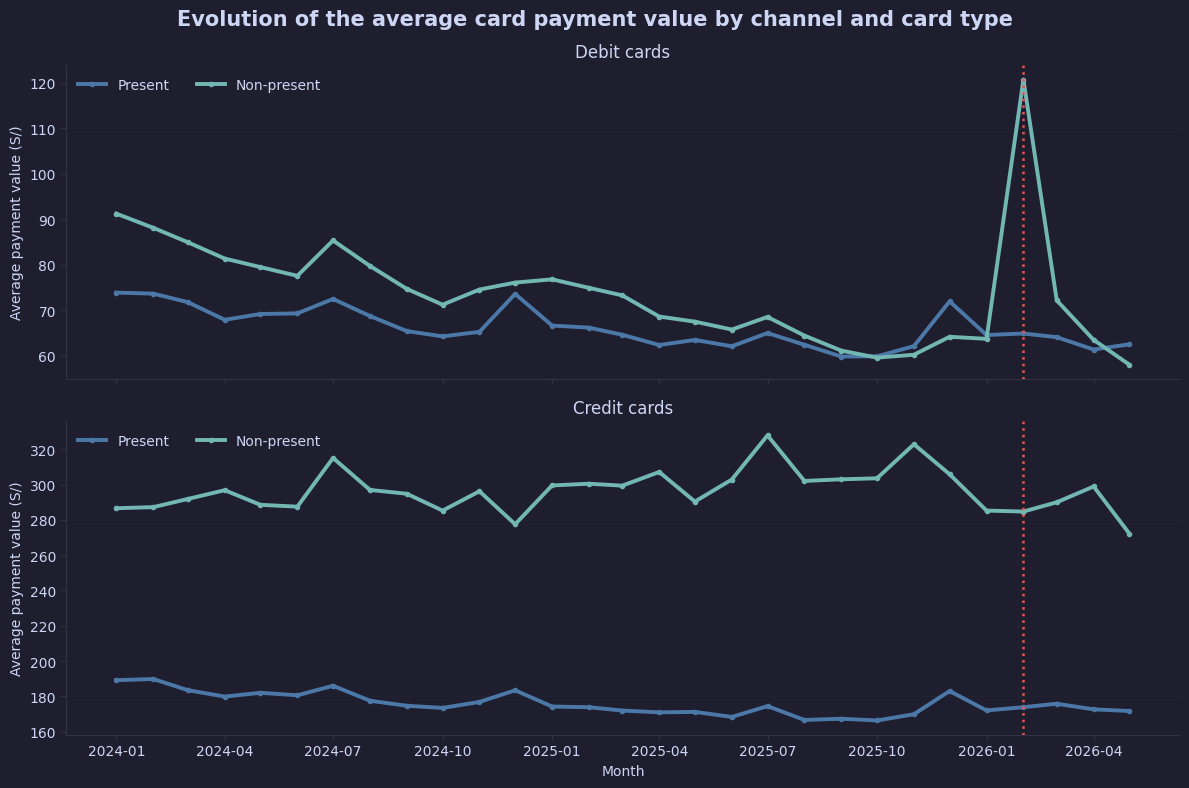

In [42]:
# Debit average tickets
channel_data["debit_avg_ticket_present"] = (
    channel_data["pago_tarjetas_debito_offline"]
    / channel_data["ntrx_tarjetas_debito_offline"]
)

channel_data["debit_avg_ticket_non_present"] = (
    channel_data["pago_tarjetas_debito_online"]
    / channel_data["ntrx_tarjetas_debito_online"]
)

# Credit average tickets
channel_data["credit_avg_ticket_present"] = (
    channel_data["pago_tarjetas_credito_offline"]
    / channel_data["ntrx_tarjetas_credito_offline"]
)

channel_data["credit_avg_ticket_non_present"] = (
    channel_data["pago_tarjetas_credito_online"]
    / channel_data["ntrx_tarjetas_credito_online"]
)

# Plot

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True,
)

present_color = "#4C78A8"
non_present_color = "#72B7B2"

# Debit cards
axes[0].plot(
    channel_data["period"],
    channel_data["debit_avg_ticket_present"],
    color=present_color,
    linewidth=2.8,
    marker="o",
    markersize=3,
    label="Present",
)

axes[0].plot(
    channel_data["period"],
    channel_data["debit_avg_ticket_non_present"],
    color=non_present_color,
    linewidth=2.8,
    marker="o",
    markersize=3,
    label="Non-present",
)

axes[0].set_title("Debit cards")
axes[0].set_ylabel("Average payment value (S/)")
axes[0].legend(frameon=False, ncol=2)

# Credit cards
axes[1].plot(
    channel_data["period"],
    channel_data["credit_avg_ticket_present"],
    color=present_color,
    linewidth=2.8,
    marker="o",
    markersize=3,
    label="Present",
)

axes[1].plot(
    channel_data["period"],
    channel_data["credit_avg_ticket_non_present"],
    color=non_present_color,
    linewidth=2.8,
    marker="o",
    markersize=3,
    label="Non-present",
)

axes[1].set_title("Credit cards")
axes[1].set_ylabel("Average payment value (S/)")
axes[1].set_xlabel("Month")
axes[1].legend(frameon=False, ncol=2)

# General formatting
for ax in axes:
    ax.axvline(
        pd.Timestamp("2026-02-01"),
        color="#E45756",
        linestyle=":",
        linewidth=1.8,
    )

    ax.grid(axis="y", alpha=0.20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Evolution of the average card payment value by channel and card type",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

# OFfline vs online card payments

In [32]:
# Aggregate debit and credit by channel

card_payment_data["payment_non_present"] = (
    card_payment_data["pago_tarjetas_debito_online"]
    + card_payment_data["pago_tarjetas_credito_online"]
)

card_payment_data["payment_present"] = (
    card_payment_data["pago_tarjetas_debito_offline"]
    + card_payment_data["pago_tarjetas_credito_offline"]
)

card_payment_data["transactions_non_present"] = (
    card_payment_data["ntrx_tarjetas_debito_online"]
    + card_payment_data["ntrx_tarjetas_credito_online"]
)

card_payment_data["transactions_present"] = (
    card_payment_data["ntrx_tarjetas_debito_offline"]
    + card_payment_data["ntrx_tarjetas_credito_offline"]
)
card_payment_data["non_present_payment_share"] = (
    card_payment_data["payment_non_present"]
    / (card_payment_data["payment_non_present"] + card_payment_data["payment_present"])
    * 100
)

card_payment_data["non_present_transactions_share"] = (
    card_payment_data["transactions_non_present"]
    / (
        card_payment_data["transactions_non_present"]
        + card_payment_data["transactions_present"]
    )
    * 100
)

channel_data = card_payment_data.dropna(
    subset=[
        "payment_non_present",
        "payment_present",
        "transactions_non_present",
        "transactions_present",
    ]
).copy()

channel_data["present_payment_share"] = 100 - channel_data["non_present_payment_share"]

channel_data["present_transactions_share"] = (
    100 - channel_data["non_present_transactions_share"]
)

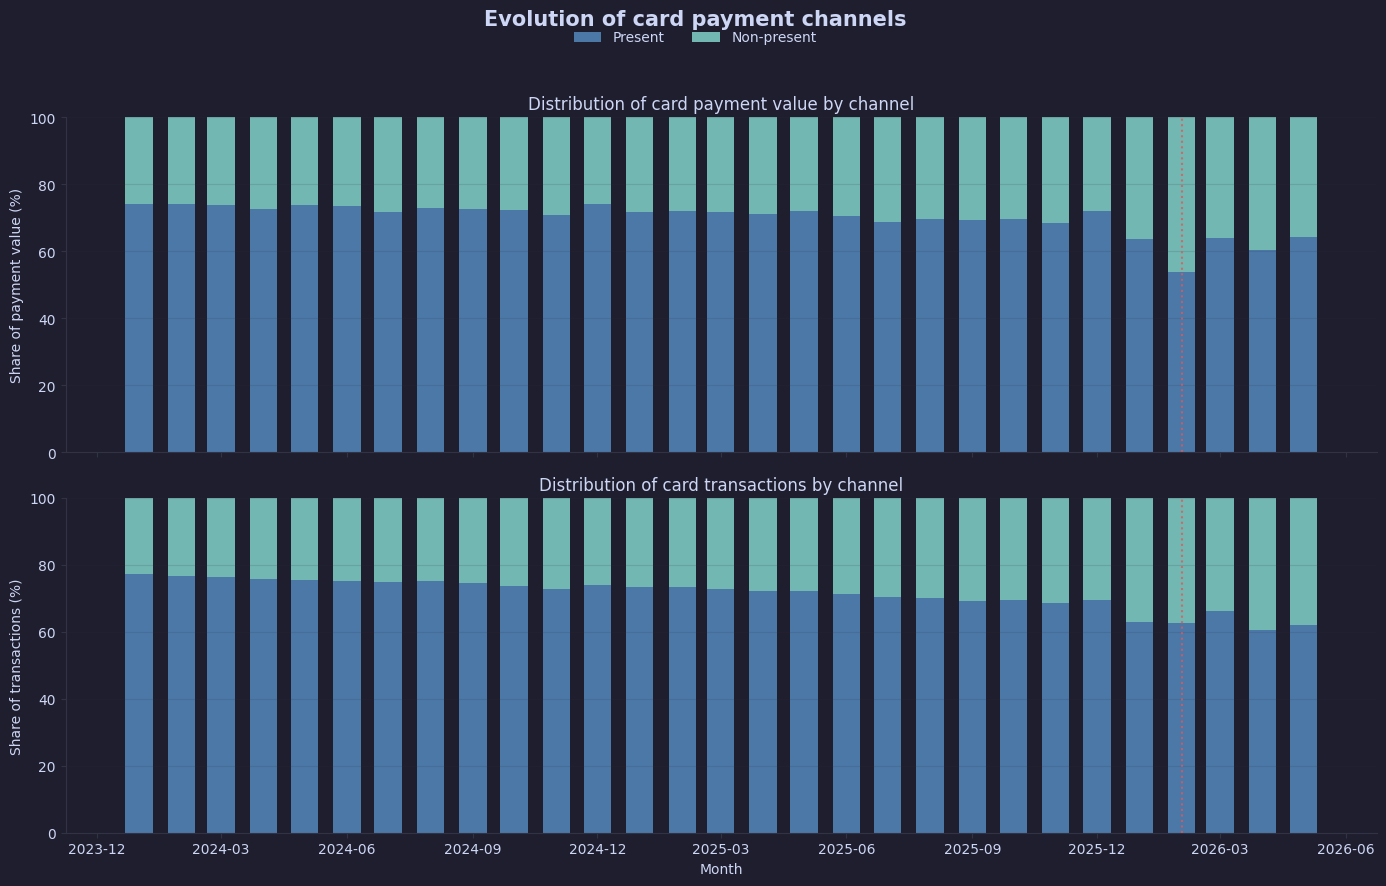

In [33]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 9),
    sharex=True,
)

present_color = "#4C78A8"
non_present_color = "#72B7B2"

# --------------------------------
# Payment-value distribution
# --------------------------------

ax1.bar(
    channel_data["period"],
    channel_data["present_payment_share"],
    width=20,
    color=present_color,
    label="Present",
)

ax1.bar(
    channel_data["period"],
    channel_data["non_present_payment_share"],
    bottom=channel_data["present_payment_share"],
    width=20,
    color=non_present_color,
    label="Non-present",
)

ax1.set_title("Distribution of card payment value by channel")
ax1.set_ylabel("Share of payment value (%)")

# --------------------------------
# Transaction distribution
# --------------------------------

ax2.bar(
    channel_data["period"],
    channel_data["present_transactions_share"],
    width=20,
    color=present_color,
    label="Present",
)

ax2.bar(
    channel_data["period"],
    channel_data["non_present_transactions_share"],
    bottom=channel_data["present_transactions_share"],
    width=20,
    color=non_present_color,
    label="Non-present",
)

ax2.set_title("Distribution of card transactions by channel")
ax2.set_ylabel("Share of transactions (%)")
ax2.set_xlabel("Month")

# --------------------------------
# Highlight February 2026
# --------------------------------

for ax in (ax1, ax2):

    ax.axvline(
        pd.Timestamp("2026-02-01"),
        color="#E45756",
        linewidth=1.5,
        linestyle=":",
        alpha=0.8,
    )

    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# One legend for the complete figure
handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.97),
)

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

fig.suptitle(
    "Evolution of card payment channels",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# Online vs off line per card type

In [35]:
# Data with channel information available
channel_data = card_payment_data.dropna(
    subset=[
        "pago_tarjetas_debito_online",
        "pago_tarjetas_debito_offline",
        "pago_tarjetas_credito_online",
        "pago_tarjetas_credito_offline",
    ]
).copy()

# Debit payment shares
channel_data["debit_payment_total"] = (
    channel_data["pago_tarjetas_debito_online"]
    + channel_data["pago_tarjetas_debito_offline"]
)

channel_data["debit_present_payment_share"] = (
    channel_data["pago_tarjetas_debito_offline"]
    / channel_data["debit_payment_total"]
    * 100
)

channel_data["debit_non_present_payment_share"] = (
    channel_data["pago_tarjetas_debito_online"]
    / channel_data["debit_payment_total"]
    * 100
)

# Credit payment shares
channel_data["credit_payment_total"] = (
    channel_data["pago_tarjetas_credito_online"]
    + channel_data["pago_tarjetas_credito_offline"]
)

channel_data["credit_present_payment_share"] = (
    channel_data["pago_tarjetas_credito_offline"]
    / channel_data["credit_payment_total"]
    * 100
)

channel_data["credit_non_present_payment_share"] = (
    channel_data["pago_tarjetas_credito_online"]
    / channel_data["credit_payment_total"]
    * 100
)

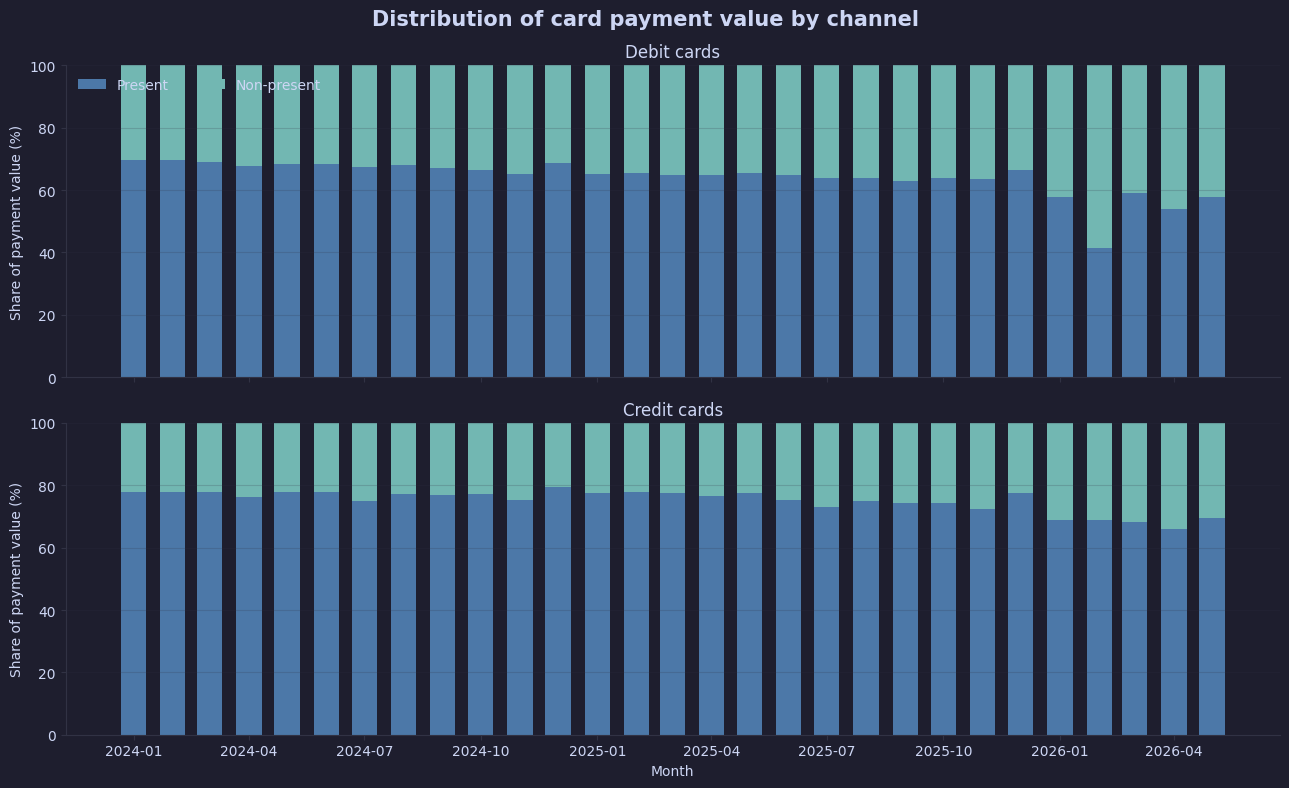

In [37]:
# Plot: payment value distribution

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 8),
    sharex=True,
    sharey=True,
)

present_color = "#4C78A8"
non_present_color = "#72B7B2"

# Debit cards
axes[0].bar(
    channel_data["period"],
    channel_data["debit_present_payment_share"],
    width=20,
    color=present_color,
    label="Present",
)

axes[0].bar(
    channel_data["period"],
    channel_data["debit_non_present_payment_share"],
    width=20,
    bottom=channel_data["debit_present_payment_share"],
    color=non_present_color,
    label="Non-present",
)

axes[0].set_title("Debit cards")
axes[0].set_ylabel("Share of payment value (%)")
axes[0].legend(frameon=False, ncol=2, loc="upper left")

# Credit cards
axes[1].bar(
    channel_data["period"],
    channel_data["credit_present_payment_share"],
    width=20,
    color=present_color,
)

axes[1].bar(
    channel_data["period"],
    channel_data["credit_non_present_payment_share"],
    width=20,
    bottom=channel_data["credit_present_payment_share"],
    color=non_present_color,
)

axes[1].set_title("Credit cards")
axes[1].set_ylabel("Share of payment value (%)")
axes[1].set_xlabel("Month")

# General formatting
for ax in axes:
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Distribution of card payment value by channel",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

In [38]:
# Debit transaction shares
channel_data["debit_transactions_total"] = (
    channel_data["ntrx_tarjetas_debito_online"]
    + channel_data["ntrx_tarjetas_debito_offline"]
)

channel_data["debit_present_transactions_share"] = (
    channel_data["ntrx_tarjetas_debito_offline"]
    / channel_data["debit_transactions_total"]
    * 100
)

channel_data["debit_non_present_transactions_share"] = (
    channel_data["ntrx_tarjetas_debito_online"]
    / channel_data["debit_transactions_total"]
    * 100
)

# Credit transaction shares
channel_data["credit_transactions_total"] = (
    channel_data["ntrx_tarjetas_credito_online"]
    + channel_data["ntrx_tarjetas_credito_offline"]
)

channel_data["credit_present_transactions_share"] = (
    channel_data["ntrx_tarjetas_credito_offline"]
    / channel_data["credit_transactions_total"]
    * 100
)

channel_data["credit_non_present_transactions_share"] = (
    channel_data["ntrx_tarjetas_credito_online"]
    / channel_data["credit_transactions_total"]
    * 100
)

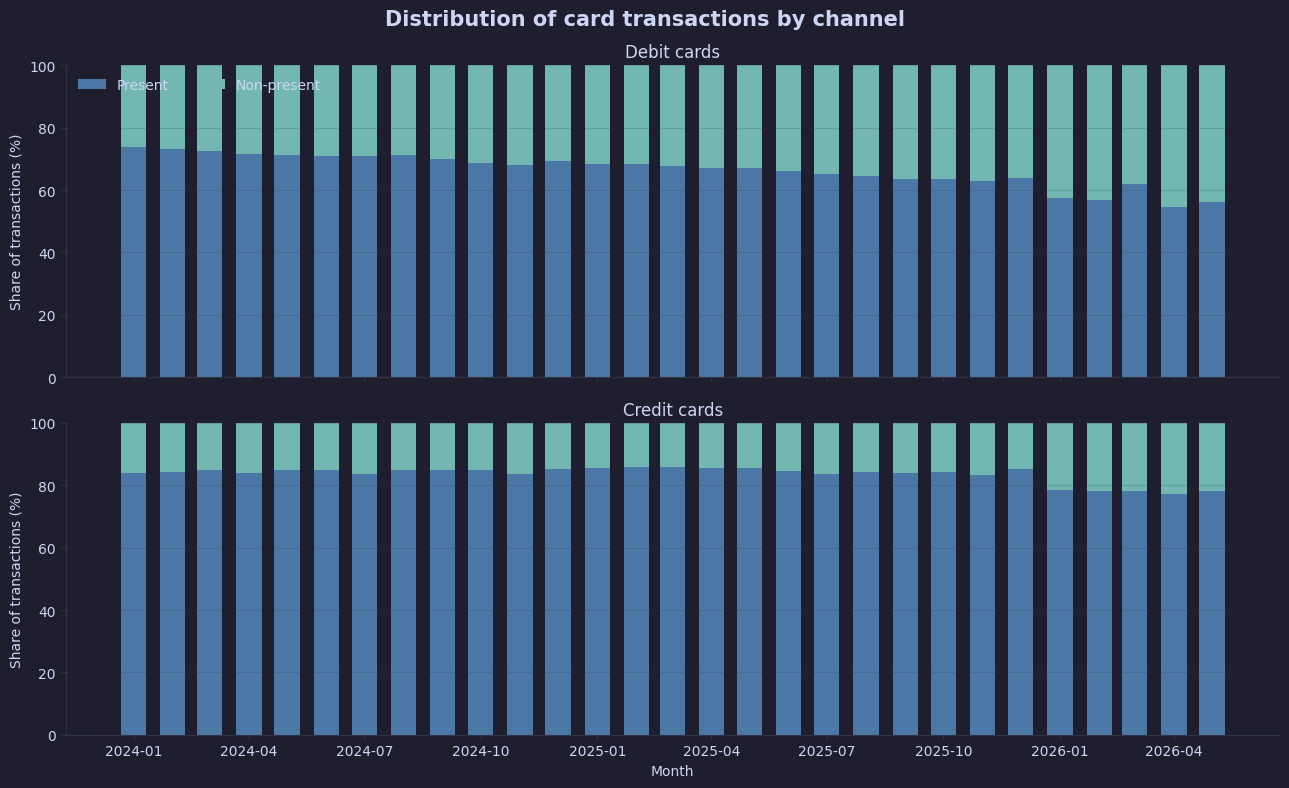

In [39]:
# Plot: transaction distribution

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 8),
    sharex=True,
    sharey=True,
)

# Debit cards
axes[0].bar(
    channel_data["period"],
    channel_data["debit_present_transactions_share"],
    width=20,
    color=present_color,
    label="Present",
)

axes[0].bar(
    channel_data["period"],
    channel_data["debit_non_present_transactions_share"],
    width=20,
    bottom=channel_data["debit_present_transactions_share"],
    color=non_present_color,
    label="Non-present",
)

axes[0].set_title("Debit cards")
axes[0].set_ylabel("Share of transactions (%)")
axes[0].legend(frameon=False, ncol=2, loc="upper left")

# Credit cards
axes[1].bar(
    channel_data["period"],
    channel_data["credit_present_transactions_share"],
    width=20,
    color=present_color,
)

axes[1].bar(
    channel_data["period"],
    channel_data["credit_non_present_transactions_share"],
    width=20,
    bottom=channel_data["credit_present_transactions_share"],
    color=non_present_color,
)

axes[1].set_title("Credit cards")
axes[1].set_ylabel("Share of transactions (%)")
axes[1].set_xlabel("Month")

# General formatting
for ax in axes:
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Distribution of card transactions by channel",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

## Main findings: average ticket and payment channels

### 1. Card payments are becoming smaller

- The average card payment value has followed a clear downward trend.
- This decline is observed in total payments and in both debit and credit cards.
- Credit cards still have a much higher average ticket than debit cards.
- By May 2026, the average ticket was approximately S/190 for credit cards and S/60 for debit cards.
- During 2026, the decline appears to have slowed, but there is not enough evidence to confirm a recovery.

This suggests that cards are increasingly being used for smaller purchases. However, it does not prove that each customer is paying more frequently because the data does not identify individual users.

### 2. Non-present channels are gaining relevance

- The non-present share increased in both payment value and number of transactions.
- At the beginning of 2024, non-present payments represented approximately 25% of value and 23% of transactions.
- In recent months, their share has moved closer to 35–40%.
- The increase is clearer and smoother in the number of transactions, suggesting that it is not explained only by changes in average ticket.

Therefore, the evidence supports a gradual shift toward non-present card payments.

### 3. Debit cards are leading the channel shift

- Debit cards show the strongest and most consistent increase in non-present participation.
- Their non-present share increased from approximately 25–30% in early 2024 to more than 40% in recent months, both in value and transactions.
- Credit cards also moved toward non-present channels, but more moderately.
- For credit cards, non-present payments currently represent approximately 30% of value and slightly above 20% of transactions.

Non-present channels are therefore more relevant within debit card payments than within credit card payments.

### 4. Channel tickets may differ by card type

- For credit cards, the non-present share of value is higher than its share of transactions.
- This indicates that non-present credit transactions have a higher average ticket than present credit transactions.
- For debit cards, value and transaction shares are much closer.
- This suggests a smaller difference between the average tickets of both debit channels.
